In [63]:
print("killme")
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import sys
import numpy as np
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import copy
import torchvision.models as models
import os, torch, numpy as np
import torch.nn as nn, torch.optim as optim
from torch.optim import lr_scheduler
from tempfile import TemporaryDirectory
from sklearn.metrics import roc_auc_score
import torchvision.models as models
import csv
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.metrics import f1_score, roc_auc_score, hamming_loss
from torchvision import transforms

killme


## Goal is to find the right defintion of hard sample and validate it accross the datasets and with different models

In [64]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_9d801795aa2d02a3bcd41ce3ae4a2cb2'

In [65]:
!kaggle datasets download -d majdoubnourelhouda/medmnist-chest-test

Dataset URL: https://www.kaggle.com/datasets/majdoubnourelhouda/medmnist-chest-test
License(s): unknown
100%|█████████████████████████████████████████| 450M/450M [00:03<00:00, 145MB/s]



In [4]:
!unzip medmnist-chest-test.zip

Archive:  medmnist-chest-test.zip
  inflating: X_Test.npy              
  inflating: Y_Test.npy              
  inflating: dataset_splits.npz      
  inflating: embeddings_raddino.npz  
  inflating: embeddings_raddino_train.npz  
  inflating: meta.json               
  inflating: testing_dataB.npz       
  inflating: train_raw.npz           
  inflating: val_dataB.npz           


In [5]:
import numpy as np
from sklearn.neighbors import NearestNeighbors


def multilabel_hardness(
    embeddings: np.ndarray,     # (N, D)  — l2-normalised recommended
    labels: np.ndarray,         # (N, L)  — binary multilabel matrix
    k: int = 15,
    w_impurity: float = 0.6,   # weight for metric 1 (neighbourhood impurity)
    w_margin: float = 0.4,     # weight for metric 2 (per-label centroid margin)
    margin_agg: str = "soft_min",  # "min" | "mean" | "soft_min"
    soft_min_temp: float = 5.0,    # temperature for soft_min aggregation
    n_jobs: int = -1,
) -> np.ndarray:
    """
    Returns a hardness score in [0, 1] for every sample.

        0.0 = easy   neighbours all agree, clear margin to correct side
        1.0 = hard   chaotic neighbourhood, no margin to correct side

    Two sub-scores are combined via weighted sum:

      Metric 1 — neighbourhood impurity  (weight w_impurity)
          Mean per-label Hamming disagreement across k-NN.
          Soft version: a neighbour sharing 13/14 labels contributes
          much less impurity than one sharing 0/14.
          Captures: how label-inconsistent is my local neighbourhood?

      Metric 2 — per-label centroid margin  (weight w_margin)
          For each label l, compute the margin of each sample to the
          global positive vs negative centroid of label l, signed by
          the sample's own label (so positive samples should be closer
          to the positive centroid and vice versa).
          Aggregated across labels via soft-min (or mean / hard-min).
          Captures: for my hardest label, am I on the geometrically
                    correct side of the decision boundary?

    Parameters
    ----------
    embeddings    : (N, D) float array — raw or pre-normalised
    labels        : (N, L) binary int/float array
    k             : number of nearest neighbours
    w_impurity    : weight for neighbourhood impurity score
    w_margin      : weight for centroid margin hardness score
    margin_agg    : how to aggregate per-label margins across L labels
                    "min"      — most sensitive to a single bad label
                    "mean"     — more robust, treats all labels equally
                    "soft_min" — smooth interpolation (recommended)
    soft_min_temp : temperature τ for soft-min; higher → closer to true min
    n_jobs        : passed to sklearn NearestNeighbors (-1 = all cores)

    Returns
    -------
    hardness : (N,) float32 array in [0, 1]
    """

    # ── 0. l2-normalise embeddings for cosine arithmetic ───────────────
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10
    emb = embeddings / norms                                # (N, D) unit sphere

    N, L = labels.shape
    labels = labels.astype(np.float32)

    # ── 1. fit k-NN (reused by metric 1) ───────────────────────────────
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine", n_jobs=n_jobs)
    nbrs.fit(emb)
    _, indices = nbrs.kneighbors(emb)
    nbr_idx = indices[:, 1:]                               # drop self → (N, k)

    # ── METRIC 1 : soft neighbourhood impurity (Hamming-based) ─────────
    #
    #   For each sample i and each neighbour j, compute the fraction of
    #   labels that disagree: mean over L of (label_i != label_j).
    #   Then average that disagreement across all k neighbours.
    #
    #   Unlike exact-match impurity, this gives partial credit:
    #   a neighbour sharing 13/14 labels ≈ 0.07 impurity contribution
    #   a neighbour sharing  0/14 labels ≈ 1.00 impurity contribution
    #
    nbr_labels = labels[nbr_idx]                           # (N, k, L)
    label_disagreement = (nbr_labels != labels[:, None, :]).astype(np.float32)
    # mean over labels → per-neighbour disagreement, then mean over neighbours
    impurity = label_disagreement.mean(axis=2).mean(axis=1)  # (N,) ∈ [0, 1]

    # ── METRIC 2 : per-label centroid margin ────────────────────────────
    #
    #   For each label l:
    #     pos_centroid = mean embedding of all samples where label l == 1
    #     neg_centroid = mean embedding of all samples where label l == 0
    #
    #     raw_margin_i = sim(i, pos_centroid) - sim(i, neg_centroid)
    #
    #     signed_margin_i = correct_side_i * raw_margin_i
    #       where correct_side = +1 if sample is positive for l
    #                            -1 if sample is negative for l
    #
    #     A positive signed margin means the sample is on the correct
    #     geometric side. A negative margin means it has crossed the
    #     boundary — maximally hard for that label.
    #
    per_label_margins = np.zeros((N, L), dtype=np.float32)

    for l in range(L):
        pos_mask = labels[:, l] == 1
        neg_mask = labels[:, l] == 0

        # skip degenerate labels (all positive or all negative)
        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            per_label_margins[:, l] = 0.0   # neutral — no information
            continue

        pos_centroid = emb[pos_mask].mean(axis=0)
        neg_centroid = emb[neg_mask].mean(axis=0)

        pos_centroid /= np.linalg.norm(pos_centroid) + 1e-10
        neg_centroid /= np.linalg.norm(neg_centroid) + 1e-10

        sim_pos = emb @ pos_centroid                       # (N,) cosine sim
        sim_neg = emb @ neg_centroid                       # (N,)

        raw_margin = sim_pos - sim_neg                     # (N,) ∈ [-2, 2]

        # flip sign for negative samples so that "correct side" always = positive margin
        correct_side = labels[:, l] * 2 - 1               # +1 if pos, -1 if neg
        per_label_margins[:, l] = correct_side * raw_margin

    # ── aggregate per-label margins across L labels ─────────────────────
    if margin_agg == "min":
        agg_margin = per_label_margins.min(axis=1)         # (N,)

    elif margin_agg == "mean":
        agg_margin = per_label_margins.mean(axis=1)        # (N,)

    elif margin_agg == "soft_min":
        τ = soft_min_temp
        agg_margin = -τ * np.log(
            np.exp(-per_label_margins / τ).mean(axis=1) + 1e-10
        )                                                  # (N,)
    else:
        raise ValueError(f"margin_agg must be 'min', 'mean', or 'soft_min', got '{margin_agg}'")
    margin_hard = 1.0 - np.clip((agg_margin + 2) / 4, 0.0, 1.0)  # (N,)


    hardness = (
        w_impurity * impurity +
        w_margin   * margin_hard
    ).astype(np.float32)

    return np.clip(hardness, 0.0, 1.0)

In [37]:
embeddings =np.load("/kaggle/input/datasets/majdoubnourelhouda/medmnist-chest-test/embeddings_raddino_train.npz")

In [38]:
print(embeddings)

NpzFile '/kaggle/input/datasets/majdoubnourelhouda/medmnist-chest-test/embeddings_raddino_train.npz' with keys: features, labels


In [39]:
features=embeddings["features"]
labels=embeddings["labels"]

In [40]:
print(features.shape,labels.shape)

(78468, 768) (78468, 14)


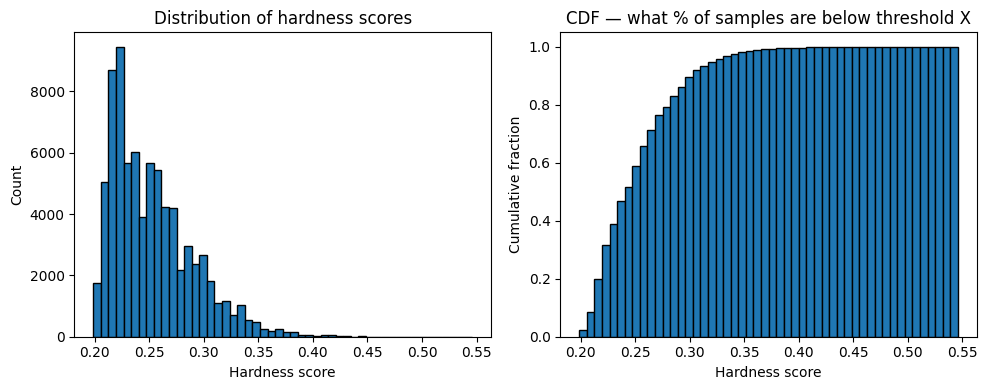

min:    0.199
max:    0.546
mean:   0.253
median: 0.245
top 10% threshold: 0.305


In [10]:
import matplotlib.pyplot as plt

hardness = multilabel_hardness(features, labels)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(hardness, bins=50, edgecolor='black')
plt.xlabel("Hardness score")
plt.ylabel("Count")
plt.title("Distribution of hardness scores")

plt.subplot(1, 2, 2)
plt.hist(hardness, bins=50, cumulative=True, density=True, edgecolor='black')
plt.xlabel("Hardness score")
plt.ylabel("Cumulative fraction")
plt.title("CDF — what % of samples are below threshold X")

plt.tight_layout()
plt.show()

print(f"min:    {hardness.min():.3f}")
print(f"max:    {hardness.max():.3f}")
print(f"mean:   {hardness.mean():.3f}")
print(f"median: {np.median(hardness):.3f}")
print(f"top 10% threshold: {np.percentile(hardness, 90):.3f}")

# this is to see what the hardness scores are like
since raddino is very smarty pants we dont have clear seperation? all samples are hard in some way so we have same score of hardness , so this multiplication wont help much (if you were planning to pultiply by hardness)

In [41]:
print(len(hardness))

78468


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


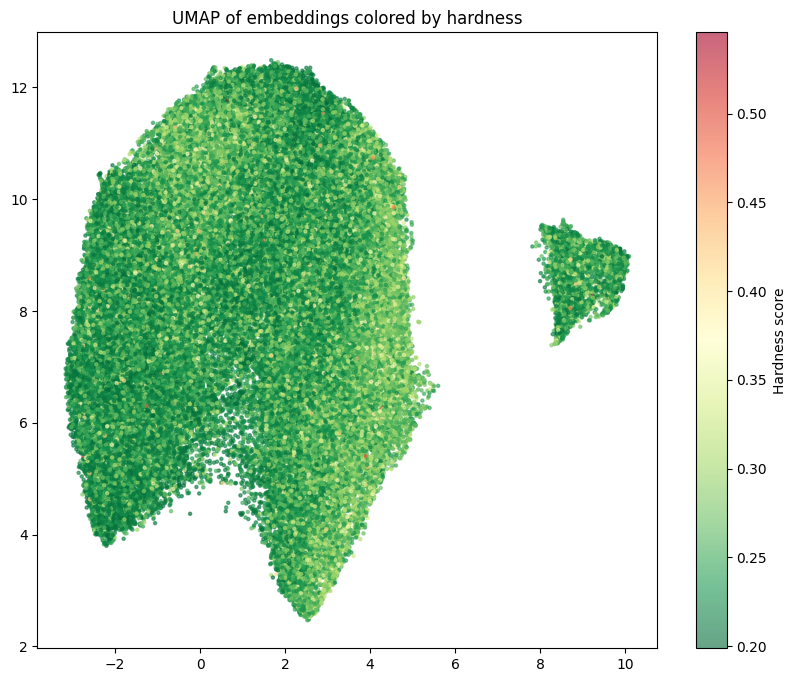

In [12]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
proj = reducer.fit_transform(features)  # (N, 2)

plt.figure(figsize=(10, 8))
sc = plt.scatter(proj[:, 0], proj[:, 1],
                 c=hardness, cmap='RdYlGn_r',  # red=hard, green=easy
                 s=5, alpha=0.6)
plt.colorbar(sc, label='Hardness score')
plt.title("UMAP of embeddings colored by hardness")
plt.show()

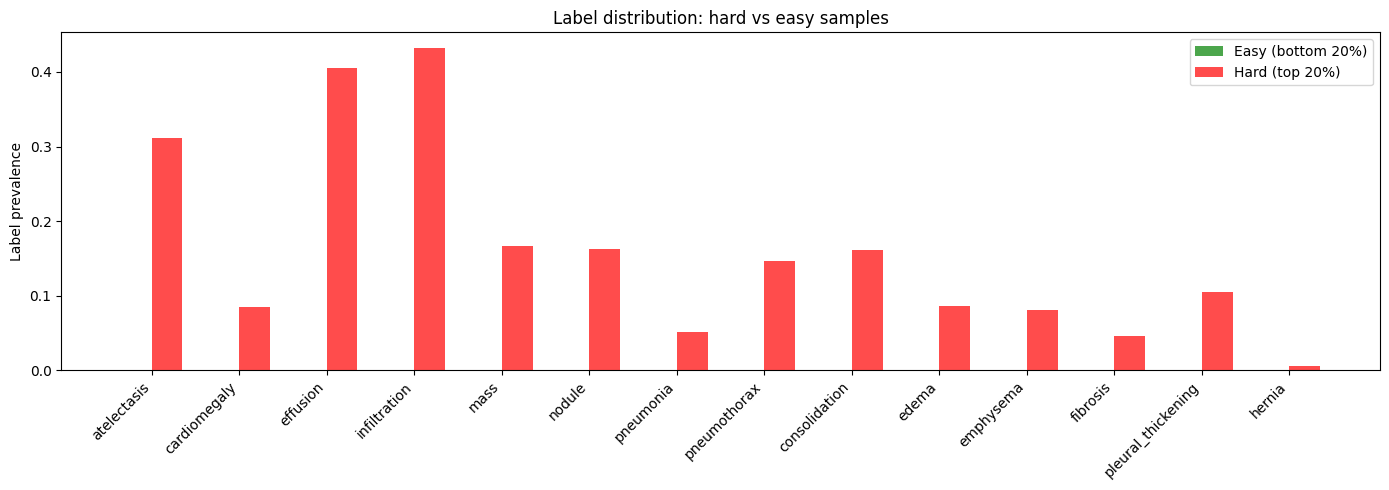

In [13]:
label_names = [
    'atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
    'mass', 'nodule', 'pneumonia', 'pneumothorax',
    'consolidation', 'edema', 'emphysema', 'fibrosis',
    'pleural_thickening', 'hernia'
]

threshold = np.percentile(hardness, 80)  # top 20% = hard
hard_mask = hardness >= threshold
easy_mask = hardness < np.percentile(hardness, 20)  # bottom 20% = easy

hard_labels = labels[hard_mask]
easy_labels = labels[easy_mask]

# prevalence of each label in hard vs easy
hard_prev  = hard_labels.mean(axis=0)
easy_prev  = easy_labels.mean(axis=0)

x = np.arange(len(label_names))
width = 0.35

plt.figure(figsize=(14, 5))
plt.bar(x - width/2, easy_prev, width, label='Easy (bottom 20%)', color='green', alpha=0.7)
plt.bar(x + width/2, hard_prev, width, label='Hard (top 20%)',  color='red',   alpha=0.7)
plt.xticks(x, label_names, rotation=45, ha='right')
plt.ylabel("Label prevalence")
plt.title("Label distribution: hard vs easy samples")
plt.legend()
plt.tight_layout()
plt.show()

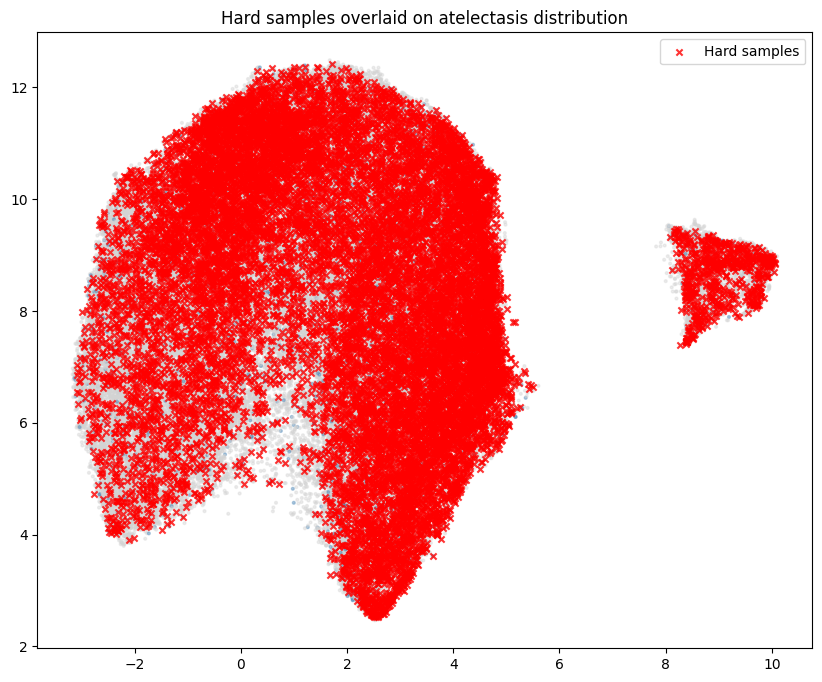

In [14]:
# pick one label to inspect at a time
label_idx = 0  # e.g. Atelectasis
label_name = label_names[label_idx]

hard_mask = hardness >= np.percentile(hardness, 80)

plt.figure(figsize=(10, 8))

# background: color by this label
colors = ['steelblue' if labels[i, label_idx] == 1 else 'lightgray'
          for i in range(len(labels))]
plt.scatter(proj[:, 0], proj[:, 1], c=colors, s=4, alpha=0.4)

# overlay hard samples as red X marks
plt.scatter(proj[hard_mask, 0], proj[hard_mask, 1],
            c='red', s=20, marker='x', alpha=0.8, label='Hard samples')

plt.title(f"Hard samples overlaid on {label_name} distribution")
plt.legend()
plt.show()

## Integration attmpt1

In [11]:
!git clone https://github.com/NoorMajdoub/Corset_selection_papers.git

Cloning into 'Corset_selection_papers'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 216 (delta 24), reused 0 (delta 0), pack-reused 161 (from 1)
Receiving objects: 100% (216/216), 940.05 KiB | 33.57 MiB/s, done.
Resolving deltas: 100% (89/89), done.


In [12]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import sys
import numpy as np
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from math import sqrt
import random
import time

!pip install faiss-cpu



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 78.0 MB/s eta 0:00:00:00:0100:01


In [13]:
base="/kaggle/working/Corset_selection_papers"
sys.path.append(base)  #so you can use the functions from the repo you cloned

In [14]:
import faiss


In [15]:
from goodCore.Experiments.Code.utils import get_dataset,load_embeddings,get_model_radDino,generate_embeddings,save_embeddings
from goodCore.Experiments.Code.selection_algo import GreedyCoreset
import pandas as pd
from sklearn.model_selection import ParameterGrid
from Evaluation.get_stat_metrics import run_and_save_stat_tests
from goodCore.Experiments.Code.utils import get_model_radDino,generate_embeddings
from sklearn.model_selection import ParameterGrid


In [42]:
def get_samples(corpus, C_set, size_samples):
    candidates = list(set(range(len(corpus))) - C_set)
    if len(candidates) <= size_samples:
        return candidates
    return random.sample(candidates, size_samples)

In [43]:
class WeightedGreedyCoreset:
    def __init__(self, corpus, labels, metric, n_neighbors,hardness_scores):
        self.corpus = np.array(corpus, dtype=np.float32)
        self.labels = np.array(labels)
        self.n = len(corpus)
        self.metric = metric
        self.n_neighbors = n_neighbors

        # Compute inverse frequency weights per sample
        self.sample_weights = self._compute_weights()

        # Build FAISS index ; used for the knn to make it faster in case of using cosine
        d = self.corpus.shape[1]
        if metric == 'cosine':
            faiss.normalize_L2(self.corpus)
            self.index = faiss.IndexFlatIP(d)
        else:
            self.index = faiss.IndexFlatL2(d)
        if faiss.get_num_gpus() > 0:
            self.index = faiss.index_cpu_to_all_gpus(self.index)
        self.index.add(self.corpus)

        #--------------Compute hardness
        h = hardness_scores
        # rescale to [0, 1] relative to this dataset
        h_min, h_max = h.min(), h.max()
        self.hardness = (h - h_min) / (h_max - h_min + 1e-10)
    def _dist(self, a, b):
                if self.metric == "euclidean":
                    return np.linalg.norm(a - b)
                elif self.metric == "cosine":
                    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    def _compute_all_dists(self, point):
        if self.metric == 'euclidean':
            return np.linalg.norm(self.corpus - point, axis=1)
        elif self.metric == 'cosine':
            point_norm = point / (np.linalg.norm(point) + 1e-10)
            return 1 - self.corpus @ point_norm
    def select(self, corset_size, sample_size, per_label=False):
            print(sample_size, self.n_neighbors, self.metric)
            return self._selectfast(corset_size, sample_size)
    def _compute_weights(self):
        #Inverse frequency weight per sample: rare class → high weight.
        labels = self.labels

        # Handle multi-label (ChestMNIST): labels shape (N, C)
        if labels.ndim == 2:
            # Weight = mean inverse frequency across positive labels
            class_counts = labels.sum(axis=0) + 1e-6  # (C,)
            class_weights = 1.0 / class_counts         # (C,)
            class_weights /= class_weights.sum()       # normalize

            # Per-sample weight = sum of weights of its positive classes
            sample_weights = (labels * class_weights).sum(axis=1)  # (N,)
        else:
            # Single-label
            unique, counts = np.unique(labels, return_counts=True)
            freq = dict(zip(unique, counts))
            sample_weights = np.array([1.0 / freq[l] for l in labels], dtype=np.float32)

        # Normalize to [1, max_boost] range — avoid extreme values
        w_min, w_max = sample_weights.min(), sample_weights.max()
        if w_max > w_min:
            sample_weights = 1.0 + 6.0 * (sample_weights - w_min) / (w_max - w_min)
        else:
            sample_weights = np.ones(self.n, dtype=np.float32)

        return sample_weights
    
    
    def _selectfast(self, corset_size, sample_size):
            import torch
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
            corpus_t = torch.tensor(self.corpus, device=device)
            combined_t = torch.tensor(
                0.6 * self.sample_weights + 0.4 * self.hardness, device=device
            )
        
            C = []
            set_c = set()
            min_dists = torch.full((self.n,), float('inf'), device=device)
        
            if corset_size > 0:
                mean = corpus_t.mean(dim=0)
                mean = mean / (mean.norm() + 1e-10)
                if self.metric == 'cosine':
                    first_dists = 1 - corpus_t @ mean
                else:
                    first_dists = (corpus_t - mean).norm(dim=1)
                first_idx = int(first_dists.argmax())
                C.append(first_idx)
                set_c.add(first_idx)
                if self.metric == 'cosine':
                    min_dists = 1 - corpus_t @ corpus_t[first_idx]
                else:
                    min_dists = (corpus_t - corpus_t[first_idx]).norm(dim=1)
        
            in_coreset = torch.zeros(self.n, dtype=torch.bool, device=device)
            in_coreset[first_idx] = True

            while len(C) < corset_size:
                candidates = get_samples(self.corpus, set_c, size_samples=sample_size)
                cand_vecs = corpus_t[torch.tensor(candidates, device=device)]
        
                if self.metric == 'cosine':
                    dist_matrix = 1 - cand_vecs @ corpus_t.T
                else:
                    dist_matrix = torch.cdist(cand_vecs, corpus_t)
        
                improvement = torch.clamp(min_dists.unsqueeze(0) - dist_matrix, min=0)
                improvement[:, in_coreset] = 0
        
                utility = (improvement * combined_t.unsqueeze(0)).sum(dim=1)
                best_local = int(utility.argmax())
                best_t = candidates[best_local]
        
                C.append(best_t)
                set_c.add(best_t)
                in_coreset[best_t] = True
                min_dists = torch.minimum(min_dists, dist_matrix[best_local])
        
                if len(C) % 100 == 0:
                    print(f"Selected {len(C)}/{corset_size}")
        
            return C    
    def _select(self, corset_size, sample_size):
        C = []
        set_c = set()
        min_dists = np.full(self.n, np.inf)

        if corset_size > 0:
            mean = np.mean(self.corpus, axis=0)
            mean = mean / (np.linalg.norm(mean) + 1e-10)
            first_idx = int(np.argmax(self._compute_all_dists(mean)))
            C.append(first_idx)
            set_c.add(first_idx)
            min_dists = self._compute_all_dists(self.corpus[first_idx])

        while len(C) < corset_size:
            candidates = get_samples(self.corpus, set_c, size_samples=sample_size)
            best_t = None
            best_utility = -np.inf

            for t in candidates:
                query = self.corpus[t].reshape(1, -1)
                dist_to_t, indexes = self.index.search(query, self.n_neighbors)
                dist_to_t = dist_to_t[0]
                indexes = indexes[0]

                if self.metric == 'cosine':
                    dist_to_t = 1 - dist_to_t
                if self.metric == 'euclidean':
                    dist_to_t = np.sqrt(dist_to_t)

                reduction = 0
                for j, i in enumerate(indexes):
                    if i in set_c:
                        continue
                    if dist_to_t[j] < min_dists[i]:
                        #  KEY CHANGE: weight the contribution by rarity of neighbor
                        reduction += (0.6*self.sample_weights[i] +0.4*(self.hardness[i]))*(min_dists[i] - dist_to_t[j])

                if reduction > best_utility:
                    best_utility = reduction
                    best_t = t

            if best_t is not None:
                C.append(best_t)
                set_c.add(best_t)
                dists_to_new = self._compute_all_dists(self.corpus[best_t])
                min_dists = np.minimum(min_dists, dists_to_new)

            if len(C) % 100 == 0:
                print(f"Selected {len(C)}/{corset_size} tuples")

        return C

In [35]:
import faiss
import numpy as np

# Keep numpy arrays on CPU for faiss
features_np = features.astype(np.float32)  # make sure it's float32

index = faiss.IndexFlatIP(features_np.shape[1])
index.add(features_np)

# Then move to GPU via faiss (not torch)
if faiss.get_num_gpus() > 0:
    res = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, index)

AttributeError: 'Tensor' object has no attribute 'astype'

In [44]:

selector      = WeightedGreedyCoreset(features, labels,'euclidean', 100,hardness)  #ht is n_neighibrs



In [75]:
N=int(0.15*len(features))
print(N)
print(len(labels))

11770
78468


In [76]:
print(len(features),len(labels))

78468 78468


In [47]:
import torch

print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
12.8
2
Tesla T4


In [31]:
device = "cuda"

features = torch.from_numpy(features).to(device)
labels = torch.from_numpy(labels).to(device)


In [32]:
import faiss

# Build index on CPU
index = faiss.IndexFlatIP(features.shape[1])   # or IndexFlatL2
index.add(features)                           # `features` is a numpy array

# Move to GPU if available
if faiss.get_num_gpus() > 0:
    res = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, index)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [77]:
start = time.time()
indicesCorset = selector.select( corset_size=N, sample_size=100)
elapsed = time.time() - start

print(f"Selected {len(indices)} points in {elapsed:.2f}s")

100 100 euclidean
Selected 100/11770
Selected 200/11770
Selected 300/11770
Selected 400/11770
Selected 500/11770
Selected 600/11770
Selected 700/11770
Selected 800/11770
Selected 900/11770
Selected 1000/11770
Selected 1100/11770
Selected 1200/11770
Selected 1300/11770
Selected 1400/11770
Selected 1500/11770
Selected 1600/11770
Selected 1700/11770
Selected 1800/11770
Selected 1900/11770
Selected 2000/11770
Selected 2100/11770
Selected 2200/11770
Selected 2300/11770
Selected 2400/11770
Selected 2500/11770
Selected 2600/11770
Selected 2700/11770
Selected 2800/11770
Selected 2900/11770
Selected 3000/11770
Selected 3100/11770
Selected 3200/11770
Selected 3300/11770
Selected 3400/11770
Selected 3500/11770
Selected 3600/11770
Selected 3700/11770
Selected 3800/11770
Selected 3900/11770
Selected 4000/11770
Selected 4100/11770
Selected 4200/11770
Selected 4300/11770
Selected 4400/11770
Selected 4500/11770
Selected 4600/11770
Selected 4700/11770
Selected 4800/11770
Selected 4900/11770
Selected 50

In [78]:
np.save(f"V2E{15}_WH-CM.npy", indicesCorset)

In [80]:
print(len(indicesCorset))

11770


In [81]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import entropy
from sklearn.metrics import pairwise_distances

# ---------------------------
# Load data
# ---------------------------
X = embeddings["features"]   # shape: (N, 128) — PCA reduced
Y = embeddings["labels"]     # shape: (N, 14)

# Load your coreset indices
X_core = X[indicesCorset]
Y_core = Y[indicesCorset]


In [82]:
print(len(X),len(Y),len(X_core),len(Y_core))

78468 78468 11770 11770


In [83]:

# ---------------------------
# 1. Coverage (embedding space)
# ---------------------------
def compute_coverage(X_full, X_core):
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    X_full_t = torch.tensor(X_full, device=device)
    X_core_t = torch.tensor(X_core, device=device)
    
    # cdist in chunks to avoid OOM
    chunk_size = 1000
    min_dists = []
    for i in range(0, len(X_full_t), chunk_size):
        chunk = X_full_t[i:i+chunk_size]
        dists = torch.cdist(chunk, X_core_t)       # (chunk, coreset_size)
        min_dists.append(dists.min(dim=1).values)
    
    min_dist = torch.cat(min_dists).cpu().numpy()
    
    return {
        "mean_min_dist": np.mean(min_dist),
        "max_min_dist": np.max(min_dist),
        "std_min_dist": np.std(min_dist)
    }

coverage_stats = compute_coverage(X, X_core)

# ---------------------------
# 2. Diversity (within coreset)
# ---------------------------
def compute_diversity(X_core):
    dists = pairwise_distances(X_core)
    return {
        "mean_pairwise_dist": np.mean(dists),
        "std_pairwise_dist": np.std(dists)
    }

diversity_stats = compute_diversity(X_core)

# ---------------------------
# 3. Label distribution comparison
# ---------------------------
def label_distribution(Y):
    # multilabel → frequency per class
    return Y.sum(axis=0) / Y.shape[0]

full_dist = label_distribution(Y)
core_dist = label_distribution(Y_core)

# ---------------------------
# 4. KL Divergence (distribution shift)
# ---------------------------
def kl_divergence(p, q, eps=1e-8):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return entropy(p, q)

kl_div = kl_divergence(full_dist, core_dist)

# ---------------------------
# 5. Coverage in label space (optional)
# ---------------------------


# ---------------------------
# Print results
# ---------------------------
print("===== COVERAGE (Embedding Space) =====")
for k, v in coverage_stats.items():
    print(f"{k}: {v:.4f}")

print("\n===== DIVERSITY (Coreset) =====")
for k, v in diversity_stats.items():
    print(f"{k}: {v:.4f}")

print("\n===== LABEL DISTRIBUTION =====")
print("Full:", full_dist)
print("Core:", core_dist)

print("\n===== KL DIVERGENCE =====")
print(f"KL(full || core): {kl_div:.6f}")

def per_class_recall(Y_full, Y_core):
    # number of positives per class in full data
    full_pos = Y_full.sum(axis=0)

    # number of positives per class in coreset
    core_pos = Y_core.sum(axis=0)

    # avoid division by zero
    recall = np.divide(
        core_pos,
        full_pos,
        out=np.zeros_like(core_pos, dtype=float),
        where=full_pos != 0
    )

    return recall, full_pos, core_pos


recall, full_pos, core_pos = per_class_recall(Y, Y_core)

print("===== PER-CLASS RECALL (Coreset Coverage) =====")
for i, r in enumerate(recall):
    print(f"Class {i:02d}: recall = {r:.4f}  ({core_pos[i]}/{full_pos[i]})")

===== COVERAGE (Embedding Space) =====
mean_min_dist: 2.8568
max_min_dist: 5.8926
std_min_dist: 1.2879

===== DIVERSITY (Coreset) =====
mean_pairwise_dist: 7.4875
std_pairwise_dist: 1.6476

===== LABEL DISTRIBUTION =====
Full: [0.10190141 0.02485089 0.11802263 0.17732069 0.05082327 0.05575521
 0.01246368 0.0472167  0.04158383 0.02153744 0.02292654 0.01475761
 0.02904369 0.00183514]
Core: [0.18870008 0.09082413 0.25242141 0.30084962 0.12625319 0.12115548
 0.07782498 0.11750212 0.13262532 0.10671198 0.09201359 0.07646559
 0.10475786 0.01223449]

===== KL DIVERGENCE =====
KL(full || core): 0.064489
===== PER-CLASS RECALL (Coreset Coverage) =====
Class 00: recall = 0.2778  (2221/7996)
Class 01: recall = 0.5482  (1069/1950)
Class 02: recall = 0.3208  (2971/9261)
Class 03: recall = 0.2545  (3541/13914)
Class 04: recall = 0.3726  (1486/3988)
Class 05: recall = 0.3259  (1426/4375)
Class 06: recall = 0.9366  (916/978)
Class 07: recall = 0.3733  (1383/3705)
Class 08: recall = 0.4784  (1561/3263)

# Fine tuunning resuts

In [54]:
NUM_CLASSES = 14
CLASS_NAMES = [
    'atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
    'mass', 'nodule', 'pneumonia', 'pneumothorax',
    'consolidation', 'edema', 'emphysema', 'fibrosis',
    'pleural_thickening', 'hernia'
]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.hub.load('facebookresearch/deit:main', 'deit_base_patch16_224', pretrained=True)
print(model.default_cfg)
train=np.load("/kaggle/input/datasets/majdoubnourelhouda/medmnist-chest-test/train_raw.npz")
X_train=train['X']
Y_train=train['Y']
print(len(X_train),len(Y_train))
print(X_train.min(), X_train.max())  # should be 0.0 and 1.0
val=np.load("/kaggle/input/datasets/majdoubnourelhouda/medmnist-chest-test/val_dataB.npz")
X_val=val['X']
Y_val=val['Y']
print(len(X_val),len(Y_val))
print(X_val.min(), X_val.max())  # should be 0.0 and 1.0
test=np.load("/kaggle/input/datasets/majdoubnourelhouda/medmnist-chest-test/testing_dataB.npz")
X_test=test['X']
Y_test=test['Y']
print(len(X_test),len(Y_test))
print(X_test.min(), X_test.max())  # should be 0.0 and 1.0


Using cache found in /root/.cache/torch/hub/facebookresearch_deit_main


{'url': '', 'num_classes': 1000, 'input_size': (3, 224, 224), 'pool_size': None, 'crop_pct': 0.9, 'interpolation': 'bicubic', 'fixed_input_size': True, 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'first_conv': 'patch_embed.proj', 'classifier': 'head', 'license': 'apache-2.0'}
78468 78468
0.0 0.99215686
11219 11219
0.0 0.99215686
22433 22433
0.0 0.99215686


In [55]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),       
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std= [0.5, 0.5, 0.5]
    )                                
])
class ChestDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, transform=None):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.Y         = torch.tensor(Y, dtype=torch.float32)
        self.transform = transform
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img   = self.X[idx]
        label = self.Y[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# creating the dataset ckass
train_dataset = ChestDataset(X, Y, transform=transform)
val_dataset   = ChestDataset(X_val,   Y_val,   transform=transform)
test_dataset  = ChestDataset(X_test,  Y_test,  transform=transform)

class ChestMNISTModel(nn.Module):
    def __init__(self, num_classes=14, strategy="end_to_end"):
        super().__init__()
        self.encoder = torch.hub.load(
            'facebookresearch/deit:main',
            'deit_base_patch16_224',
            pretrained=True
        )
        self.encoder.head = nn.Linear(
            self.encoder.head.in_features, num_classes
        )
        if strategy == "linear_probing":
            for name, param in self.encoder.named_parameters():
                if "head" not in name:
                    param.requires_grad = False
        else:
            for param in self.encoder.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.encoder(x)
def build_optimizer(model, strategy="end_to_end"):
    if strategy == "linear_probing":
        return torch.optim.AdamW(
            model.encoder.head.parameters(), lr=1e-3
        )
    else:
        return torch.optim.AdamW([
            {"params": [p for n, p in model.encoder.named_parameters()
                        if "head" not in n],       "lr": 1e-5},
            {"params": model.encoder.head.parameters(), "lr": 1e-3},
        ])

def build_scheduler(optimizer, steps_per_epoch):
    return torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=steps_per_epoch,  # decay every 1 epoch instead of every 200 iters
        gamma=0.9
    )
criterion = nn.BCEWithLogitsLoss()  #yessssssss

def find_best_thresholds(model, val_loader, device):
    model.to(device)
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            all_logits.append(model(imgs.to(device)).cpu())
            all_labels.append(lbls)
    
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    
    positives_per_class = labels.sum(axis=0)
    print(f"Positives per class: {dict(zip(CLASS_NAMES, positives_per_class.astype(int)))}")
    
    best_thresholds = []
    for i, name in enumerate(CLASS_NAMES):
        best_t, best_f1 = 0.2, 0
        for t in np.arange(0.05, 0.95, 0.05):
            f1 = f1_score(labels[:, i], probs[:, i] >= t, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresholds.append(best_t)
        print(f"{name}: best_threshold={best_t:.2f}, f1={best_f1:.4f}")
    
    return best_thresholds
def evaluate(model, loader, device, thresholds=None):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            all_logits.append(model(imgs.to(device)).cpu())
            all_labels.append(lbls)
    
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    
    # apply thresholds — per-class if provided, fixed 0.2 otherwise
    if thresholds is not None:
        preds = np.zeros_like(probs, dtype=int)
        for i, t in enumerate(thresholds):
            preds[:, i] = (probs[:, i] >= t).astype(int)
    else:
        preds = (probs >= 0.2).astype(int)
    
    hamming  = hamming_loss(labels, preds)
    f1_micro = f1_score(labels, preds, average='micro', zero_division=0)
    f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
    f1_per   = f1_score(labels, preds, average=None,    zero_division=0)
    
    auc_per_class = {}
    for i, name in enumerate(CLASS_NAMES):
        auc_per_class[name] = (
            roc_auc_score(labels[:, i], probs[:, i])
            if len(np.unique(labels[:, i])) > 1 else float('nan')
        )
    valid    = [v for v in auc_per_class.values() if not np.isnan(v)]
    mean_auc = float(np.mean(valid))
    
    return {
        "f1_micro"     : f1_micro,
        "f1_macro"     : f1_macro,
        "hamming"      : hamming,
        "macro_auc"    : mean_auc,
        "auc_per_class": auc_per_class,
        "f1_per_class" : {name: float(f1_per[i])
                          for i, name in enumerate(CLASS_NAMES)},
    }

def train(
    model, train_loader, val_loader, optimizer, scheduler,
    criterion, device, num_epochs,
    # ── early stopping knobs ──────────────────────────────────────
    es_patience=3,      # stop after this many eval steps with no gain
    es_min_delta=1e-4,  # minimum AUC improvement to count as real
    eval_every=2,       # evaluate on val every N epochs
    # ─────────────────────────────────────────────────────────────
):
    """
    Train with early stopping on macro_AUC.

    Returns
    -------
    model   : model with best-validation weights restored
    history : dict with lists 'epoch', 'val_auc', 'val_f1_macro', 'val_hamming'
              — useful for plotting and comparing coreset runs
    """
    early_stopper = EarlyStopping(
        patience=es_patience,
        min_delta=es_min_delta,
        mode='max',
        verbose=True,
    )
    
    history = {'epoch': [], 'val_auc': [], 'val_f1_macro': [], 'val_hamming': []}

    print(f"steps per epoch: {len(train_loader)}, total epochs: {num_epochs}")

    for epoch in range(1, num_epochs + 1):
        # ── train one epoch ──
        model.train()
        epoch_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)

        # ── validate every eval_every epochs ──
        if epoch % eval_every == 0 or epoch == num_epochs:
            metrics = evaluate(model, val_loader, device, thresholds=None)
            val_auc = metrics['macro_auc']

            print(
                f"Epoch {epoch:>3}/{num_epochs} | "
                f"train_loss={avg_loss:.4f} | "
                f"val_AUC={val_auc:.4f} | "
                f"val_F1_macro={metrics['f1_macro']:.4f} | "
                f"val_hamming={metrics['hamming']:.4f}"
            )

            history['epoch'].append(epoch)
            history['val_auc'].append(val_auc)
            history['val_f1_macro'].append(metrics['f1_macro'])
            history['val_hamming'].append(metrics['hamming'])

            # ── early stopping check — saves best weights internally ──
            stop = early_stopper.step(val_auc, model)
            model.train()   # put back in train mode after evaluate()

            if stop:
                print(f"\n⏹  Early stopping triggered at epoch {epoch} "
                      f"(best val_AUC={early_stopper.best_score:.4f})")
                break

    # ── restore best weights ──
    if early_stopper.best_weights is not None:
        model.load_state_dict(early_stopper.best_weights)
    print(f"\n✓ Best val AUC: {early_stopper.best_score:.4f} — restored best weights")

    return model, history
class EarlyStopping:

    def __init__(self, patience=3, min_delta=1e-3, mode='max', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.verbose    = verbose

        self.best_score   = None
        self.counter      = 0
        self.should_stop  = False
        self.best_weights = None          # kept externally in train()

    def step(self, score, model):

        improved = (
            self.best_score is None or
            (self.mode == 'max' and score > self.best_score + self.min_delta) or
            (self.mode == 'min' and score < self.best_score - self.min_delta)
        )

        if improved:
            self.best_score   = score
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.verbose:
                print(f"  [EarlyStopping] no improvement for {self.counter}/{self.patience} checks "
                      f"(best={self.best_score:.4f})")
            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop
def run_experiment(X_train, Y_train, X_val, Y_val, X_test, Y_test,
                   strategy="end_to_end",
                   subset_indices=None,
                   experiment_name="full",num_epochs=10,
                    es_patience=3,
                    es_min_delta=1e-3,
                    eval_every=1,
                  ):

    # Corset subset
    if subset_indices is not None:
        X_tr = X_train[subset_indices]
        Y_tr = Y_train[subset_indices]
    else:
        X_tr, Y_tr = X_train, Y_train
    print(f"Working on {len(X_tr)} and {len(Y_tr)}")
    print(f"\n{'='*60}")
    print(f"Experiment: {experiment_name} | train size: {len(X_tr)}")
    print(f"{'='*60}")

    # data loaders
    train_loader = DataLoader(
        ChestDataset(X_tr,     Y_tr,     transform=transform),
        batch_size=32, shuffle=True,  num_workers=2
    )
    val_loader   = DataLoader(
        ChestDataset(X_val,   Y_val,   transform=transform),
        batch_size=64, shuffle=False, num_workers=2
    )
    test_loader  = DataLoader(
        ChestDataset(X_test,  Y_test,  transform=transform),
        batch_size=64, shuffle=False, num_workers=2
    )

    model     = ChestMNISTModel(strategy=strategy).to(device)
    optimizer = build_optimizer(model, strategy=strategy)
    scheduler = build_scheduler(optimizer, steps_per_epoch=len(train_loader))

    criterion = nn.BCEWithLogitsLoss()
    total_iters = num_epochs * len(train_loader)
    model, history = train(
        model, train_loader, val_loader, optimizer, scheduler,
        criterion, device,
        num_epochs=num_epochs,
        es_patience=es_patience,
        es_min_delta=es_min_delta,
        eval_every=eval_every,
    )

    #we get the threshold after the model is trained :)))
    thresholds=find_best_thresholds(model, val_loader, device)
    # final evaluation on test
    metrics = evaluate(model, test_loader, device,thresholds)
    print(f"\n[{experiment_name}] FINAL TEST RESULTS:")
    print(f"  macro_AUC : {metrics['macro_auc']:.4f}")
    print(f"  F1_macro  : {metrics['f1_macro']:.4f}")
    print(f"  F1_micro  : {metrics['f1_micro']:.4f}")
    print(f"  hamming   : {metrics['hamming']:.4f}")

    return metrics,history
results = {}


In [56]:
import numpy as np

def random_coreset(labels, selection_rate: float = None, coreset_size: int = None, seed: int = 42):
    """
    Randomly select a coreset from a dataset.

    Pass either selection_rate (fraction of N) or coreset_size (absolute count).

    Returns
    -------
    indices : np.ndarray of selected indices
    """
    N = len(labels)
    
    if coreset_size is None and selection_rate is None:
        raise ValueError("Pass either selection_rate or coreset_size")
    if coreset_size is None:
        coreset_size = max(1, int(np.ceil(selection_rate * N)))

    rng = np.random.default_rng(seed)
    indices = rng.choice(N, size=coreset_size, replace=False)
    return indices

In [86]:
indicesRandom = random_coreset(labels, selection_rate=0.15,seed=33)
print(len(indicesRandom))


11771


In [84]:
idx = np.load(
        "/kaggle/input/datasets/notnour/cm-c-wh/V2E15_WH-CM.npy"
)


In [ ]:
metrics,history = run_experiment(
        X_train, Y_train, X_val, Y_val, X_test, Y_test,
        strategy        = "end to end",
        subset_indices  = indicesRandom,
        experiment_name = f"full.pct",
        num_epochs      = 15, 
        es_patience     = 3,
        es_min_delta    = 1e-4,
        eval_every      = 1, 
        
        
    )


Working on 11771 and 11771

Experiment: full.pct | train size: 11771


Using cache found in /root/.cache/torch/hub/facebookresearch_deit_main


steps per epoch: 368, total epochs: 15
Epoch   1/15 | train_loss=0.1767 | val_AUC=0.7124 | val_F1_macro=0.0925 | val_hamming=0.0644
Epoch   2/15 | train_loss=0.1630 | val_AUC=0.7340 | val_F1_macro=0.1106 | val_hamming=0.0695


In [ ]:
print(metrics)